In [1]:
import numpy as np
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'matplotlib'

In [2]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.5 MB 972.3 kB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.5 MB 1.0 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.5 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.5 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.5 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.5 MB 1.1 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.5 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.5 MB 1.1 MB/s eta 0:00:07
   ----------- ---------------------------- 2.6/9.5 MB 1.1 MB/s eta 0:00:07
   ------------ ---------------

In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Runway direction in degrees
runway_direction = 90

# Wind measurements in knots
wind_speed = np.array([10, 15, 20, 12, 18, 25, 14])

# Wind direction in degrees
wind_direction = np.array([80, 100, 120, 70, 250, 95, 110])

n_obs = len(wind_speed)
obs_labels = [f"Obs {i+1}" for i in range(n_obs)]

# Operating limits
max_allowed_crosswind = 20   # knots
max_allowed_tailwind = 10    # knots

print("Runway Direction:", runway_direction, "deg")
print("Wind Speeds:", wind_speed, "knots")
print("Wind Directions:", wind_direction, "deg")


Runway Direction: 90 deg
Wind Speeds: [10 15 20 12 18 25 14] knots
Wind Directions: [ 80 100 120  70 250  95 110] deg


In [5]:
def wrap_angle(angle):
    """Wrap angle(s) in degrees to the range -180 to +180."""
    return (angle + 180) % 360 - 180

relative_angle = wrap_angle(wind_direction - runway_direction)
angle_rad = np.deg2rad(relative_angle)

headwind = wind_speed * np.cos(angle_rad)   # +ve = headwind, -ve = tailwind
crosswind = wind_speed * np.sin(angle_rad)  # signed, +ve = from one side
crosswind_magnitude = np.abs(crosswind)

print("Relative Wind Angles:", relative_angle)
print("Headwind/Tailwind Component:", np.round(headwind, 2), "knots")
print("Crosswind Component:", np.round(crosswind, 2), "knots")
print("Crosswind Magnitude:", np.round(crosswind_magnitude, 2), "knots")


Relative Wind Angles: [-10  10  30 -20 160   5  20]
Headwind/Tailwind Component: [  9.85  14.77  17.32  11.28 -16.91  24.9   13.16] knots
Crosswind Component: [-1.74  2.6  10.   -4.1   6.16  2.18  4.79] knots
Crosswind Magnitude: [ 1.74  2.6  10.    4.1   6.16  2.18  4.79] knots


In [6]:
max_headwind = np.max(headwind)
max_tailwind = np.min(headwind)          # most negative = worst tailwind
max_crosswind = np.max(crosswind_magnitude)

crosswind_ok = max_crosswind <= max_allowed_crosswind
tailwind_ok = abs(max_tailwind) <= max_allowed_tailwind

print("Maximum Headwind:", round(max_headwind, 2), "knots")
print("Maximum Tailwind:", round(abs(max_tailwind), 2), "knots")
print("Maximum Crosswind:", round(max_crosswind, 2), "knots")

print("\n========== RUNWAY WIND ANALYSIS ==========")
print(f"Runway Direction       : {runway_direction} deg")
print(f"Average Wind Speed     : {np.mean(wind_speed):.2f} knots")
print(f"Maximum Wind Speed     : {np.max(wind_speed)} knots")
print(f"Maximum Headwind       : {max_headwind:.2f} knots")
print(f"Maximum Tailwind       : {abs(max_tailwind):.2f} knots")
print(f"Maximum Crosswind      : {max_crosswind:.2f} knots")
print(f"Crosswind Status       : {'WITHIN LIMIT' if crosswind_ok else 'EXCEEDS LIMIT'}")
print(f"Tailwind Status        : {'WITHIN LIMIT' if tailwind_ok else 'EXCEEDS LIMIT'}")
print("\nAnalysis Completed Successfully.")


Maximum Headwind: 24.9 knots
Maximum Tailwind: 16.91 knots
Maximum Crosswind: 10.0 knots

========== RUNWAY WIND ANALYSIS ==========
Runway Direction       : 90 deg
Average Wind Speed     : 16.29 knots
Maximum Wind Speed     : 25 knots
Maximum Headwind       : 24.90 knots
Maximum Tailwind       : 16.91 knots
Maximum Crosswind      : 10.00 knots
Crosswind Status       : WITHIN LIMIT
Tailwind Status        : EXCEEDS LIMIT

Analysis Completed Successfully.


In [7]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

GREEN = "#2E7D32"
RED = "#C62828"
BLUE = "#1565C0"
ORANGE = "#EF6C00"
GRAY = "#616161"


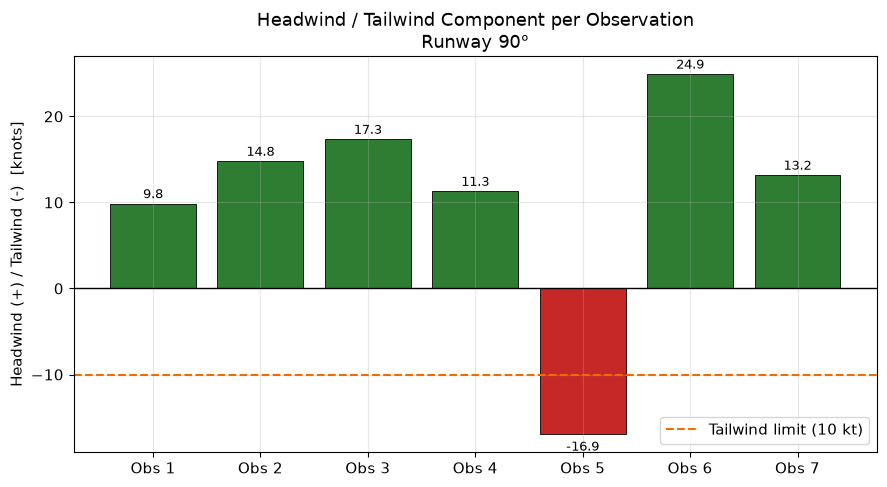

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [GREEN if h >= 0 else RED for h in headwind]
bars = ax.bar(obs_labels, headwind, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(-max_allowed_tailwind, color=ORANGE, linestyle="--", linewidth=1.5,
           label=f"Tailwind limit ({max_allowed_tailwind} kt)")
for bar, val in zip(bars, headwind):
    ax.annotate(f"{val:.1f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 4 if val >= 0 else -12),
                ha="center", fontsize=9)
ax.set_ylabel("Headwind (+) / Tailwind (-)  [knots]")
ax.set_title(f"Headwind / Tailwind Component per Observation\nRunway {runway_direction}\u00b0")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


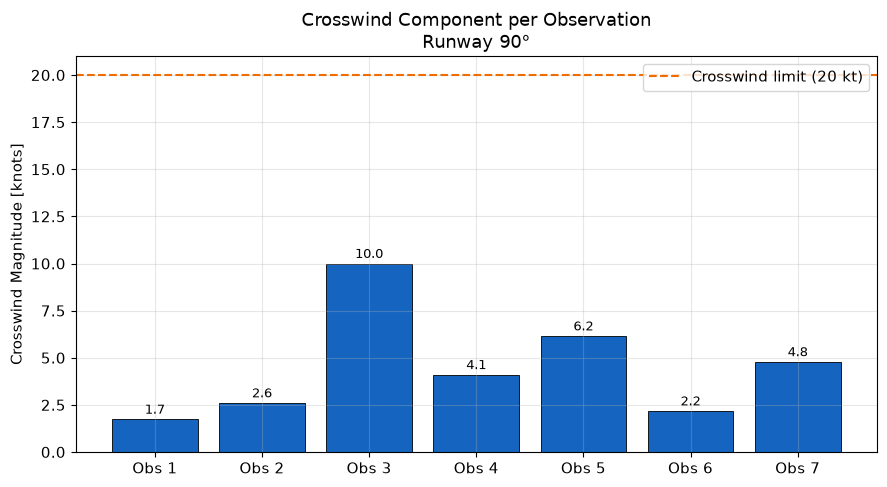

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if c > max_allowed_crosswind else BLUE for c in crosswind_magnitude]
bars = ax.bar(obs_labels, crosswind_magnitude, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(max_allowed_crosswind, color=ORANGE, linestyle="--", linewidth=1.5,
           label=f"Crosswind limit ({max_allowed_crosswind} kt)")
for bar, val in zip(bars, crosswind_magnitude):
    ax.annotate(f"{val:.1f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax.set_ylabel("Crosswind Magnitude [knots]")
ax.set_title(f"Crosswind Component per Observation\nRunway {runway_direction}\u00b0")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


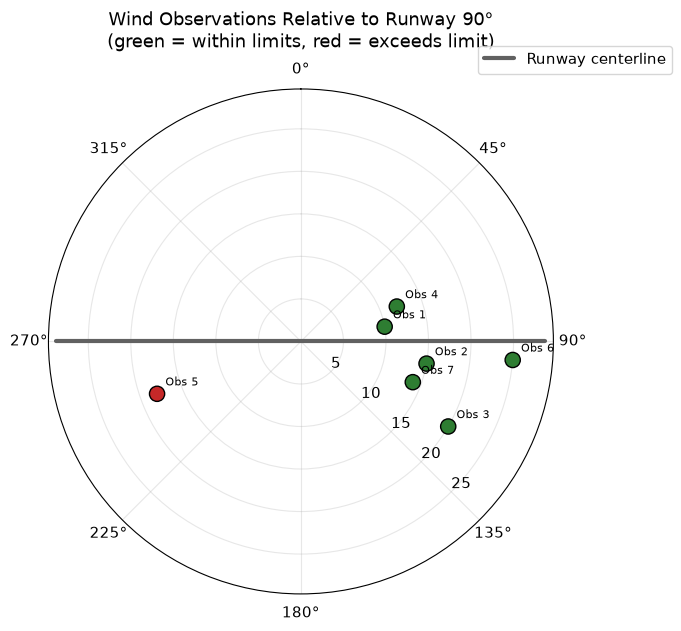

In [10]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

theta = np.deg2rad(wind_direction)
point_colors = [RED if cm > max_allowed_crosswind or hw < -max_allowed_tailwind
                else GREEN for cm, hw in zip(crosswind_magnitude, headwind)]
ax.scatter(theta, wind_speed, c=point_colors, s=120, edgecolor="black", zorder=3)

for t, r, lbl in zip(theta, wind_speed, obs_labels):
    ax.annotate(lbl, (t, r), textcoords="offset points", xytext=(6, 6), fontsize=8)

runway_theta = np.deg2rad(runway_direction)
r_max = wind_speed.max() * 1.15
ax.plot([runway_theta, runway_theta + np.pi], [r_max, r_max], color=GRAY,
        linewidth=3, solid_capstyle="round", zorder=2, label="Runway centerline")
ax.set_rlabel_position(135)
ax.set_title(f"Wind Observations Relative to Runway {runway_direction}\u00b0\n"
             f"(green = within limits, red = exceeds limit)", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
fig.tight_layout()
plt.show()


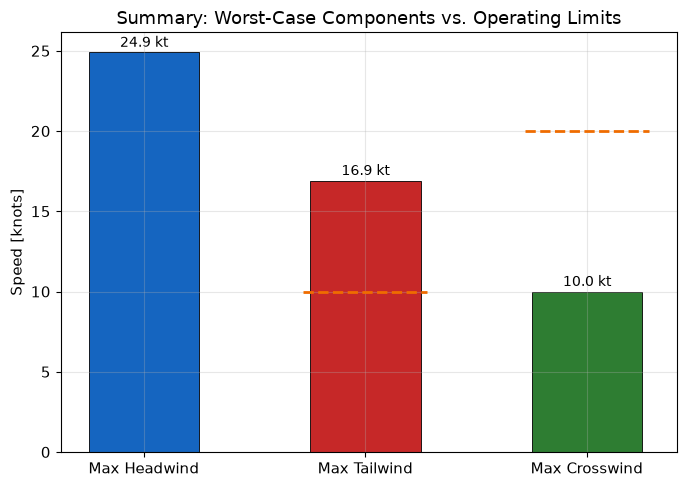

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
categories = ["Max Headwind", "Max Tailwind", "Max Crosswind"]
values = [max_headwind, abs(max_tailwind), max_crosswind]
limits = [None, max_allowed_tailwind, max_allowed_crosswind]
bar_colors = [BLUE,
              RED if abs(max_tailwind) > max_allowed_tailwind else GREEN,
              RED if max_crosswind > max_allowed_crosswind else GREEN]
bars = ax.bar(categories, values, color=bar_colors, edgecolor="black", linewidth=0.6, width=0.5)
for bar, val in zip(bars, values):
    ax.annotate(f"{val:.1f} kt", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=10)
for x, lim in zip(range(len(categories)), limits):
    if lim is not None:
        ax.plot([x - 0.28, x + 0.28], [lim, lim], color=ORANGE, linestyle="--", linewidth=2)
ax.set_ylabel("Speed [knots]")
ax.set_title("Summary: Worst-Case Components vs. Operating Limits")
fig.tight_layout()
plt.show()
